# Proyek Analisis Data: Bike sharing
- **Nama:** Raufa Ummuhani
- **Email:** raufaummuhani@gmail.com
- **ID Dicoding:** ms192d5x0633

## Menentukan Pertanyaan Bisnis

1. Apakah ada perbedaan signifikan dalam penggunaan sepeda di setiap musim?
2. Bagaimana penggunaan sepeda lebih tinggi pada hari kerja tertentu (weekday)?


## Import Semua Packages/Library yang Digunakan

In [6]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Wrangling

### Gathering Data

In [14]:
file_path = "/content/drive/My Drive/data/day.csv"
day_df = pd.read_csv(file_path)
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [13]:
file_path = "/content/drive/My Drive/data/day.csv"

hour_df = pd.read_csv(file_path)
hour_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset terdiri dari dua bagian, yaitu "day.csv" untuk data harian dan "hour.csv" untuk data per jam. Keduanya memiliki kolom terkait tanggal, cuaca, dan jumlah pengguna sepeda.


### Assessing Data

In [ ]:
day_df.info()
hour_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

In [15]:
day_df.isna().sum()
hour_df.isna().sum()


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [16]:
day_df.describe()
hour_df.describe()


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [ ]:
day_df[day_df['hum'] == 0]  # Menampilkan baris dengan kelembaban 0



**Insight:**
- Kolom dteday masih bertipe object, yang seharusnya dalam format datetime jadi day_df ini mesti diubah format menjadi datetime
- Kolom instant perlu dihapus karena hanya berupa nomor indeks yang tidak memiliki makna analitis. Data sudah memiliki kolom tanggal (dteday) yang bisa digunakan untuk analisis berbasis waktu, sehingga instant tidak memberikan informasi tambahan.
- tidak ada duplikasi data
- kelembapan / hum tidak realistis karena kelembapan udara tidak mungkin nol jadi harus lebih dari 0

### Cleaning Data

In [ ]:
print(day_df.dtypes) # Melihat tipe data
day_df['dteday'] = pd.to_datetime(day_df['dteday'])  # Mengubah ke format datetime
day_df.drop(columns=['instant'], inplace=True)  # Menghapus ID yang tidak berguna
hour_df.drop(columns=['instant'], inplace=True)  # Menghapus ID yang tidak berguna
day_df.loc[day_df['hum'] == 0, 'hum'] = day_df['hum'].median() # Menghapus hum yang tidak sesuai (0)


**Insight:**
- Mengubah format dteday menjadi datetime untuk memudahkan analisis berbasis waktu
- Menghapus kolom instant, karena tidak memberikan informasi yang berguna.
- Mengatasi nilai hum yang tidak valid (0) dengan menggantinya menggunakan median


## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



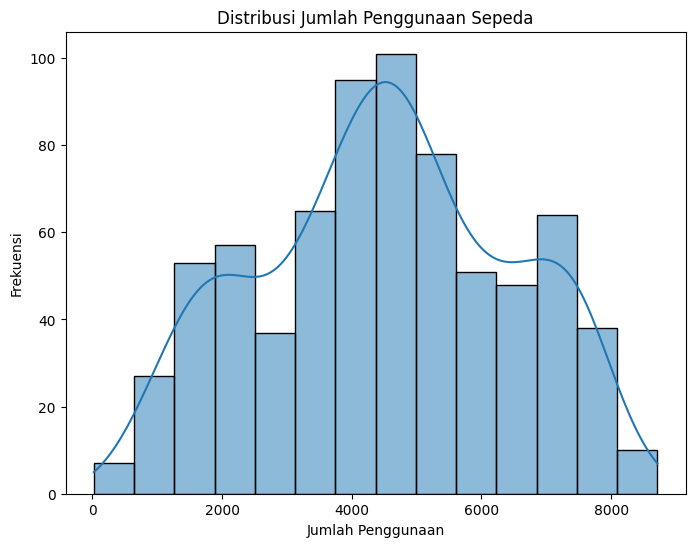

In [18]:
plt.figure(figsize=(8, 6))
sns.histplot(day_df['cnt'], kde=True)
plt.title('Distribusi Jumlah Penggunaan Sepeda')
plt.xlabel('Jumlah Penggunaan')
plt.ylabel('Frekuensi')
plt.show()


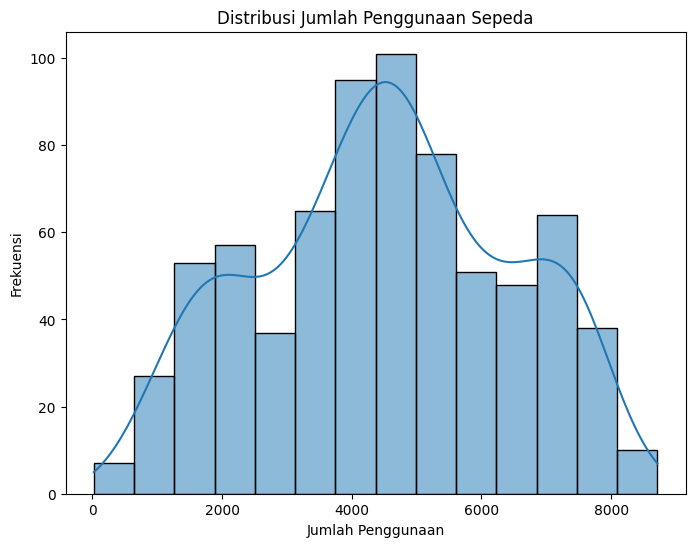

In [23]:
plt.figure(figsize=(8, 6))
sns.histplot(hour_df['cnt'], kde=True)
plt.title('Distribusi Jumlah Penggunaan Sepeda')
plt.xlabel('Jumlah Penggunaan')
plt.ylabel('Frekuensi')
plt.show()


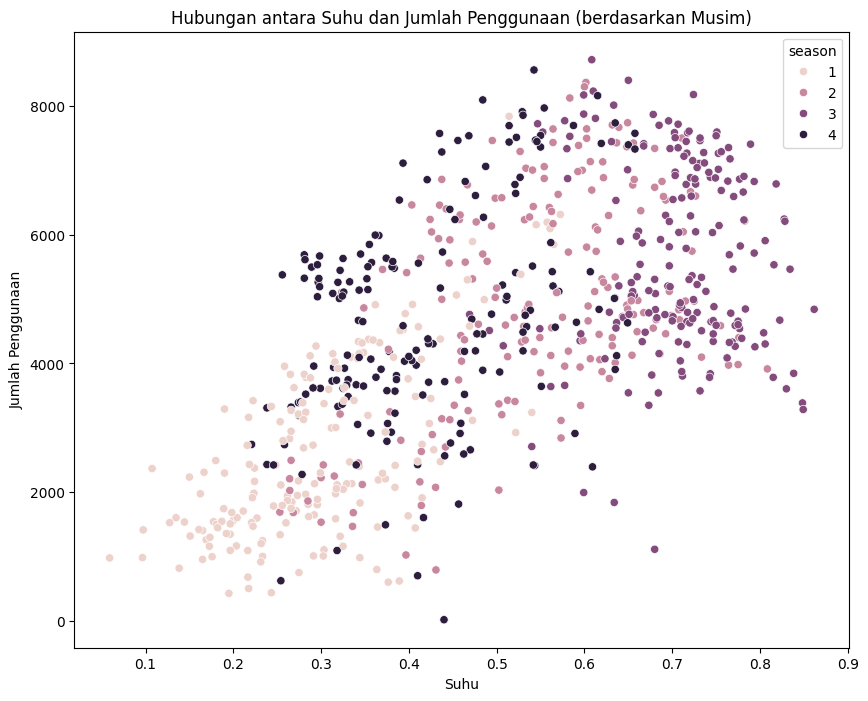

In [21]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='temp', y='cnt', data=day_df, hue='season')
plt.title('Hubungan antara Suhu dan Jumlah Penggunaan (berdasarkan Musim)')
plt.xlabel('Suhu')
plt.ylabel('Jumlah Penggunaan')
plt.show()


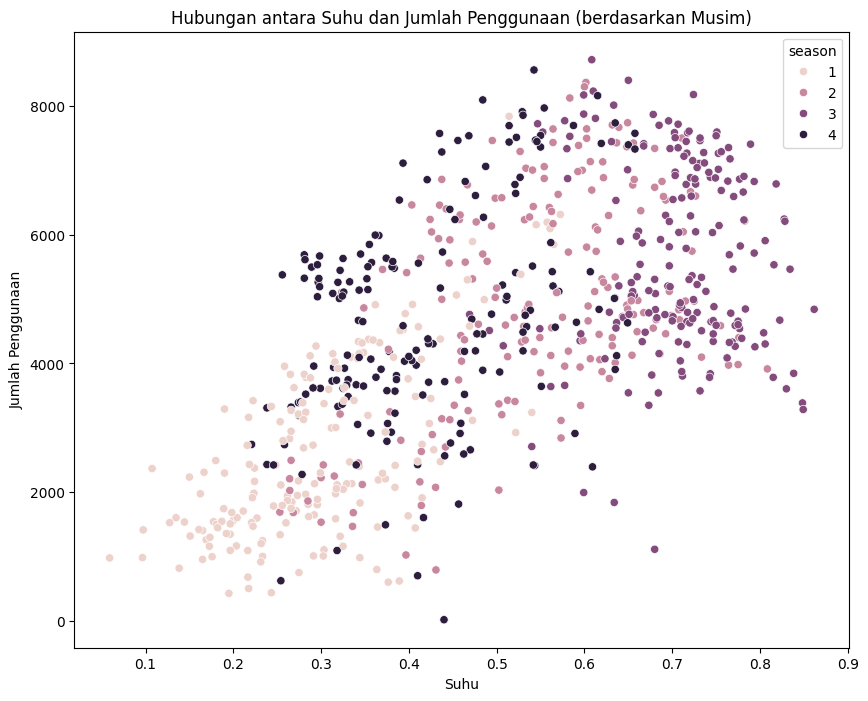

In [22]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='temp', y='cnt', data=hour_df, hue='season')
plt.title('Hubungan antara Suhu dan Jumlah Penggunaan (berdasarkan Musim)')
plt.xlabel('Suhu')
plt.ylabel('Jumlah Penggunaan')
plt.show()


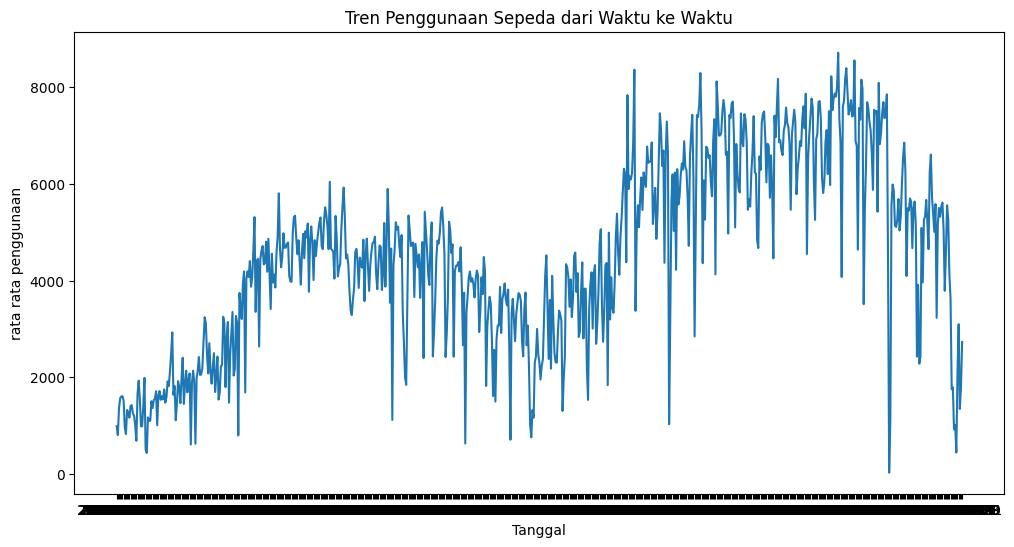

In [28]:

plt.figure(figsize=(12, 6))
plt.plot(day_df['dteday'], day_df['cnt'])
plt.title('Tren Penggunaan Sepeda dari Waktu ke Waktu')
plt.xlabel('Tanggal')
plt.ylabel('rata rata penggunaan')
plt.show()

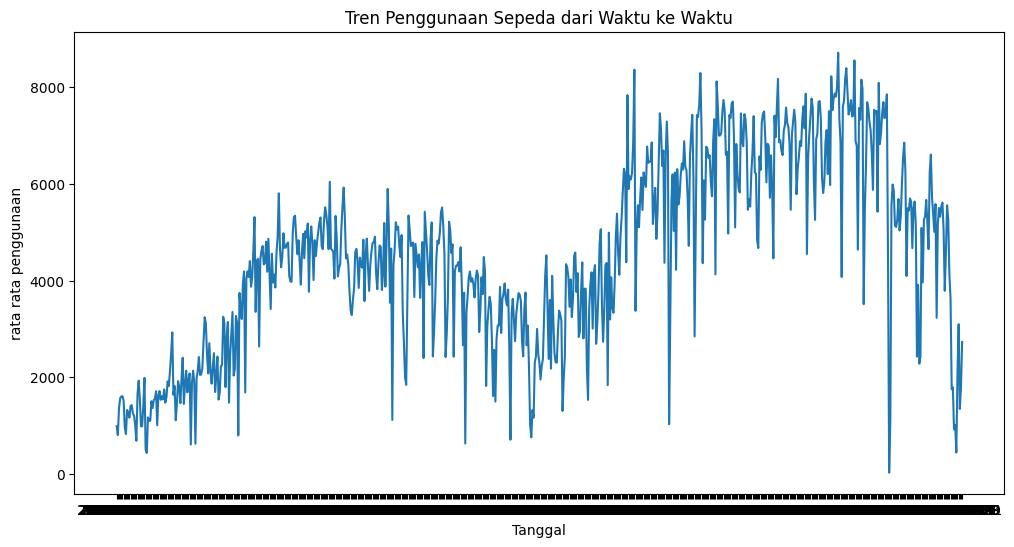

In [30]:

plt.figure(figsize=(12, 6))
plt.plot(hour_df['dteday'], hour_df['cnt'])
plt.title('Tren Penggunaan Sepeda dari Waktu ke Waktu')
plt.xlabel('Tanggal')
plt.ylabel('rata rata penggunaan')
plt.show()

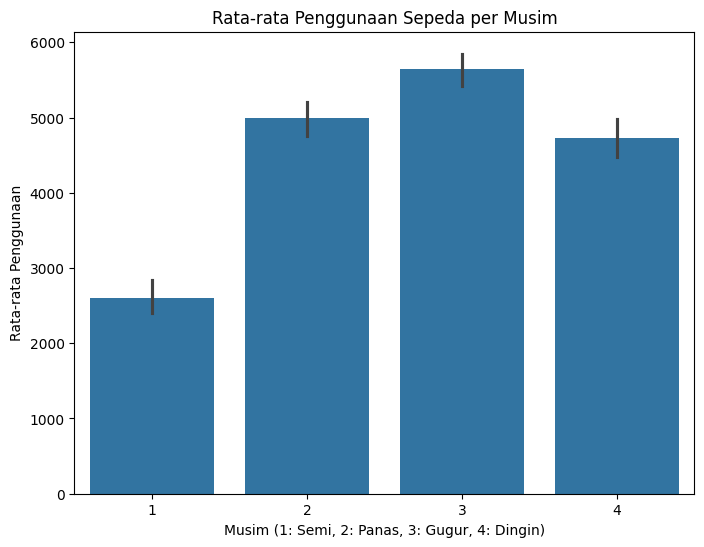

In [ ]:
# d. Penggunaan Berdasarkan Musim
plt.figure(figsize=(8, 6))
sns.barplot(x='season', y='cnt', data=day_df)
plt.title('Rata-rata Penggunaan Sepeda per Musim')
plt.xlabel('Musim (1: Semi, 2: Panas, 3: Gugur, 4: Dingin)')
plt.ylabel('Rata-rata Penggunaan')
plt.show()

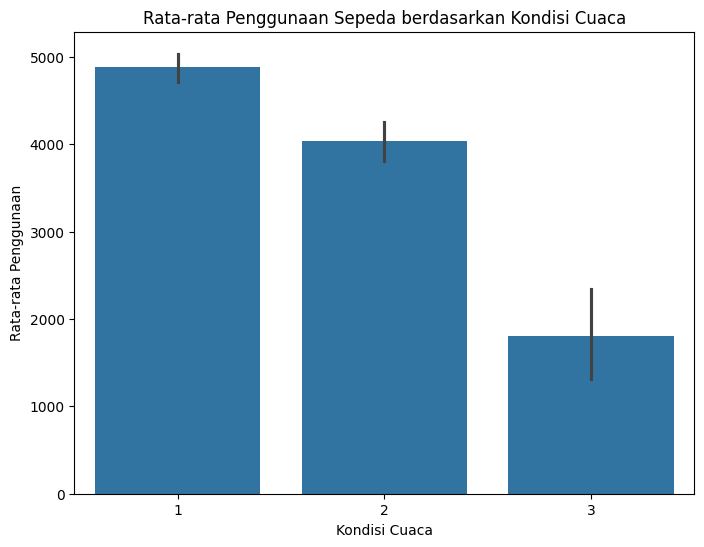

In [ ]:
# e. Penggunaan Berdasarkan Kondisi Cuaca
plt.figure(figsize=(8, 6))
sns.barplot(x='weathersit', y='cnt', data=day_df)
plt.title('Rata-rata Penggunaan Sepeda berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penggunaan')
plt.show()


Korelasi antara Suhu dan Jumlah Penggunaan: 0.6274940090334918


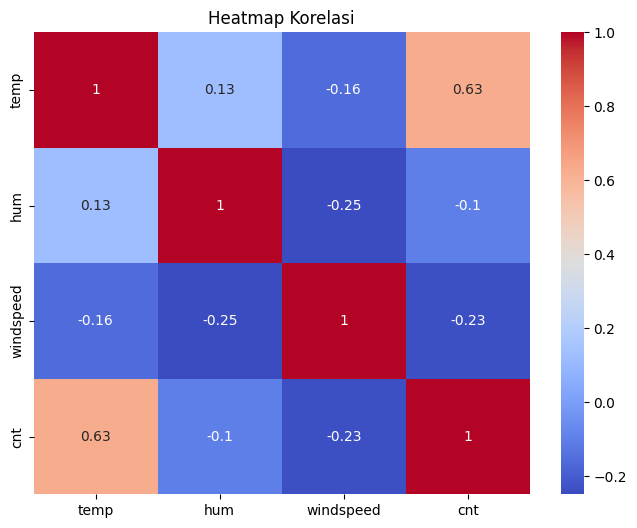

In [ ]:
### Korelasi Antar Variabel
correlation = day_df['temp'].corr(day_df['cnt'])
print(f"\nKorelasi antara Suhu dan Jumlah Penggunaan: {correlation}")

correlation_matrix = day_df[['temp', 'hum', 'windspeed', 'cnt']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

**Insight:**
-  Distribusi penggunaan sepeda menunjukksn pola tertentu, apakah ada kecenderungan penggunaan tinggi atau rendah.
- Boxplot suhu membantu mengidentifikasi outlier atau variasi suhu yang signifikan.
- Hubungan suhu dengan jumlah penggunaan sepeda dapat mengindikasikan bagaimana cuaca memengaruhi aktivitas bersepeda.
- Tren waktu menunjukkan pola musiman atau tren jangka panjang dalam penggunaan sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Apakah ada perbedaan signifikan dalam penggunaan sepeda di setiap musim?


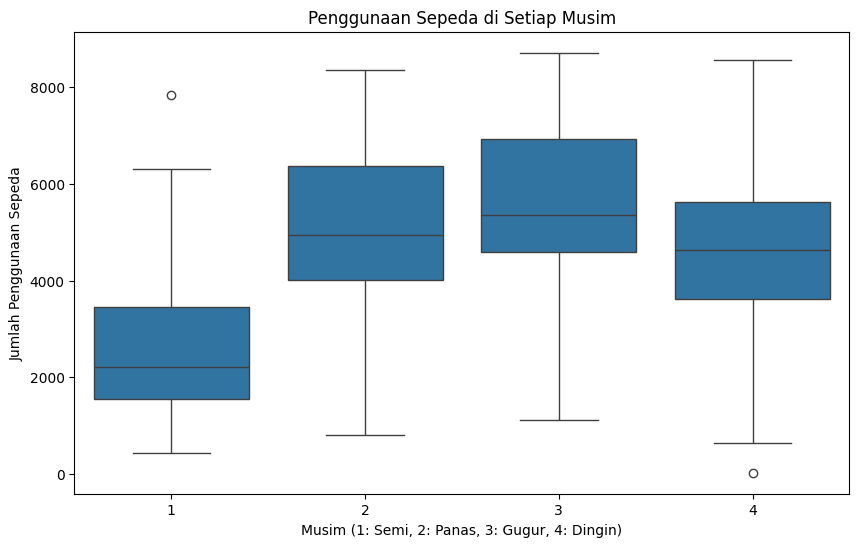

In [ ]:
# Visualisasi 1: Perbedaan penggunaan sepeda di setiap musim
plt.figure(figsize=(10, 6))
sns.boxplot(x='season', y='cnt', data=day_df)
plt.title('Penggunaan Sepeda di Setiap Musim')
plt.xlabel('Musim (1: Semi, 2: Panas, 3: Gugur, 4: Dingin)')
plt.ylabel('Jumlah Penggunaan Sepeda')
plt.show()


### Pertanyaan 2: Apakah penggunaan sepeda lebih tinggi pada hari kerja tertentu (weekday)?


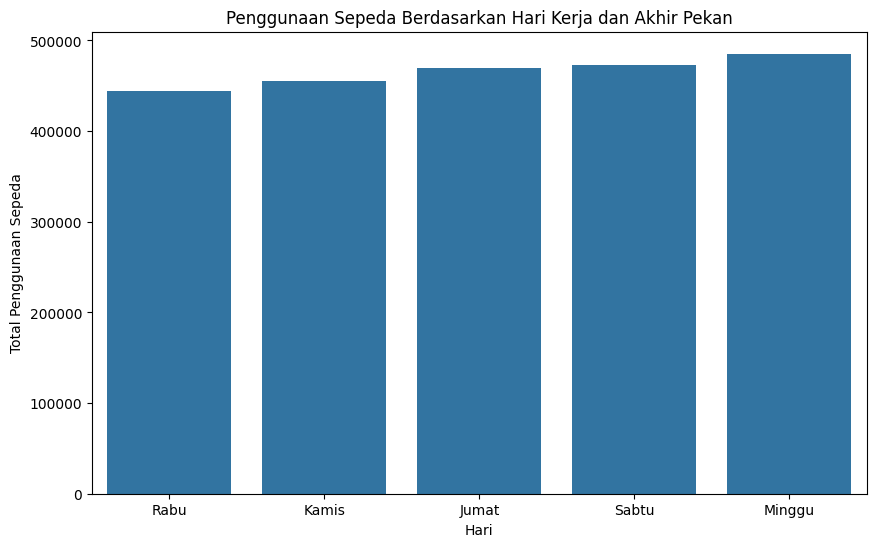

In [ ]:
weekday_mapping = {0: 'Senin', 1: 'Selasa', 2: 'Rabu', 3: 'Kamis', 4: 'Jumat', 5: 'Sabtu', 6: 'Minggu'}
day_df['weekday_name'] = day_df['weekday'].map(weekday_mapping)

plt.figure(figsize=(10, 6))
sns.barplot(x='weekday_name', y='cnt', data=day_df, estimator=sum, errorbar=None)
plt.title('Penggunaan Sepeda Berdasarkan Hari Kerja dan Akhir Pekan')
plt.xlabel('Hari')
plt.ylabel('Total Penggunaan Sepeda')
plt.show()


## Conclusion

1. Apakah ada perbedaan signifikan dalam penggunaan sepeda di setiap musim?
   berdasarkan data yg diperoleh penggunaan sepeda bervariasi signifikan di setiap musim. seperti:
-Musim dengan penyewaan tertinggi: Musim panas (Summer) dan musim gugur (Fall) menunjukkan jumlah penyewaan yang paling tinggi.
-Musim dengan penyewaan terendah: Musim dingin (Winter) memiliki jumlah penyewaan yang jauh lebih rendah dibandingkan musim lainnya.
jadi, cuaca yang lebih hangat dan kondisi jalan yang lebih baik di musim panas/gugur mendukung aktivitas bersepeda. di musim dingin, suhu rendah dan kemungkinan hujan/salju menyebabkan berkurangnya penggunaan sepeda.

2. Apakah penggunaan sepeda lebih tinggi pada hari kerja(weekday)?
   kesimpulan nya tidak ada satu hari kerja tertentu yang secara signifikan lebih tinggi dibandingkan hari lainnya. namun penggunaan sepeda cenderung lebih tinggi pada hari kerja dibandingkan akhir pekan. Hari dengan penggunaan tertinggi yaitu Senin–Jumat ini menunjukkan peningkatan jumlah penyewaan, terutama pada pagi dan sore hari. Sebaliknya hari dengan penggunaan lebih rendah yaitu hari Sabtu & Minggu yang mengalami sedikit penurunan dalam jumlah penyewaan. faktornya mungkin karna pada hari kerja, sepeda lebih sering digunakan sebagai alat transportasi untuk bekerja/sekolah. namun, pada akhir pekan, penggunaannya lebih bersifat rekreasi dan jumlah pengguna sedikit berkurang dibandingkan hari kerja.


